# S2 | Sampling Validation & Coverage

Validates the 100-question S2 sample by checking:
1. **Model results** — degradation ladder, ent/op breakdown, multimodal gains
2. **Signal validation** — does signal score predict actual degradation?
3. **Pool coverage** — sample vs full 1k accuracy distributions, t-SNE

Loads from `experiment/s2.csv` (output of `s2_sampling.ipynb`).

In [1]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

mapper = VQAAnswerMapper()

RESULTS_DIR  = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'
S2_CSV       = '/home/david/Desktop/yuna/HPA/experiment/s2.csv'

CONTROL_TYPES = ['question','deictic_removed','object_removed','weaker_object','pronominalized']
COMPLETE_MODELS = [
    'InternVL3_5-1B','InternVL3_5-2B','InternVL3_5-8B',
    'Qwen3-VL-2B-Instruct','Qwen3-VL-4B-Instruct',
    'llava-1.5-7b-hf','llava-v1.6-mistral-7b-hf',
    'llava-v1.6-vicuna-7b-hf','llava-v1.6-vicuna-13b-hf',
]

# Load sample — s2.csv already has ent/op/ent_grp/op_grp from sampling
sampled   = pd.read_csv(S2_CSV)
samp_qids = set(sampled['question_id'].tolist())
# Full sem_df for pool lookups; only merge w+ans into sampled (ent/op already there)
sem_df    = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id','ent','op','w','ans']]
sampled   = sampled.merge(sem_df[['question_id','w','ans']], on='question_id', how='left')

print(f'Loaded {len(sampled)} S2 sample questions')
print('Op distribution:', sampled['op'].value_counts().to_dict())
print('w  distribution:', sampled['w'].value_counts().to_dict())


Loaded 100 S2 sample questions
Op distribution: {'attr': 44, 'count': 15, 'spat': 14, 'ident': 11, 'act': 8, 'cause': 3, 'comp': 2, 'text': 1, 'know': 1, 'temp': 1}
w  distribution: {'what': 67, 'how_many': 15, 'which': 6, 'where': 5, 'other': 2, 'why': 2, 'how_long': 1, 'who': 1, 'how_old': 1}


---

## Model Results on Sampled Questions

Evaluates all 11 pretrained VLMs on the 100 sampled questions across all 5 control types.
Validates the sampling design (signal score, tier semantics, degradation by ent/op group).


In [2]:
import os
from collections import defaultdict
import numpy as np
from scipy.stats import pearsonr, spearmanr

RESULTS_DIR   = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
STUDY_CTS     = ['question', 'weaker_object', 'pronominalized']
CONDITIONS    = {'control': 'vqa_1k_control',
                 'blind':   'vqa_1k_control_blind',
                 'inst_blind': 'vqa_1k_control_inst_blind'}
COND_STYLE    = {
    'control':    dict(color='#2ecc71', ls='-',  marker='o', label='with image (control)'),
    'blind':      dict(color='#e74c3c', ls='--', marker='s', label='no image (blind)'),
    'inst_blind': dict(color='#3498db', ls=':',  marker='^', label='no image + instr (inst_blind)'),
}

models_all = [m for m in sorted(os.listdir(RESULTS_DIR))
              if os.path.exists(f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl')]
models_3cond = [m for m in sorted(os.listdir(RESULTS_DIR))
                if all(os.path.exists(f'{RESULTS_DIR}/{m}/{f}.jsonl') and
                       sum(1 for _ in open(f'{RESULTS_DIR}/{m}/{f}.jsonl') if _.strip()) >= 1000
                       for f in CONDITIONS.values())]

samp_qids = set(sampled['question_id'])

# Load ALL 1k questions for all 3 conditions
acc_cond = {}
for cond, fname in CONDITIONS.items():
    models_use = models_3cond if cond != 'control' else models_all
    d = defaultdict(lambda: defaultdict(dict))
    for model in models_use:
        path = f'{RESULTS_DIR}/{model}/{fname}.jsonl'
        if not os.path.exists(path): continue
        with open(path) as f:
            for line in f:
                ex  = json.loads(line)
                qid = ex['question_id']
                gt  = mapper.get_answers(qid)
                for ct in CONTROL_TYPES:
                    ans = ex.get('generated_answers', {}).get(ct, '').strip()
                    if ans and gt:
                        d[qid][model][ct] = vqa_accuracy(ans, gt)
    acc_cond[cond] = d

acc_data  = acc_cond['control']
pool_qids = set(acc_cond['control'].keys())

print(f'models_all (control)  : {len(models_all)}')
print(f'models_3cond (all 3)  : {len(models_3cond)}')
print(f'Pool questions loaded : {len(pool_qids)}')
print(f'Sample questions      : {len(samp_qids)}')

# Build long-form res_df: all 1k questions x 3 conditions x control_types
ENT3 = {'object':'object','person':'person','animal':'other_ent','food':'other_ent',
        'place':'other_ent','vehicle':'other_ent','other':'other_ent','text':'other_ent','product':'other_ent'}
OP3  = {'attr':'attr','count':'count','exist':'other_op','spat':'other_op','ident':'other_op',
        'act':'other_op','text':'other_op','know':'other_op','comp':'other_op',
        'cause':'other_op','temp':'other_op','other':'other_op'}

rows_analysis = []
for cond, models_use in [('control', models_all), ('blind', models_3cond), ('inst_blind', models_3cond)]:
    for qid in acc_cond[cond].keys():
        dataset = 'sample' if qid in samp_qids else 'pool'
        meta = sampled[sampled.question_id == qid].iloc[0] if dataset == 'sample' else None
        sem_row = sem_df[sem_df.question_id == qid]
        ent_raw = sem_row['ent'].values[0] if len(sem_row) else 'other'
        op_raw  = sem_row['op'].values[0]  if len(sem_row) else 'other'
        for ct in CONTROL_TYPES:
            accs = [acc_cond[cond][qid][m][ct] for m in models_use
                    if ct in acc_cond[cond][qid].get(m, {})]
            if not accs: continue
            row = {
                'question_id' : qid,
                'condition'   : cond,
                'dataset'     : dataset,
                'control_type': ct,
                'mean_acc'    : np.mean(accs),
                'ent_grp'     : ENT3.get(ent_raw, 'other_ent'),
                'op_grp'      : OP3.get(op_raw, 'other_op'),
                'acc_range'   : meta['acc_range']    if meta is not None else np.nan,
                'signal_score': meta['signal_score'] if meta is not None else np.nan,
                'inst_acc_orig': meta.get('inst_acc_orig', np.nan) if meta is not None else np.nan,
            }
            rows_analysis.append(row)

res_df = pd.DataFrame(rows_analysis)
print(f'\nres_df rows: {len(res_df)}')
print(res_df.groupby(['condition','dataset']).size().unstack())


   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...


   ✓ Loaded 214354 VQA annotations


models_all (control)  : 10
models_3cond (all 3)  : 9
Pool questions loaded : 1000
Sample questions      : 100



res_df rows: 15000
dataset     pool  sample
condition               
blind       4500     500
control     4500     500
inst_blind  4500     500


### Degradation Ladder Validation

Confirms that the 5-step control hierarchy produces monotonic accuracy decay,
and validates the skip decisions (`deictic_removed`, `object_removed`).


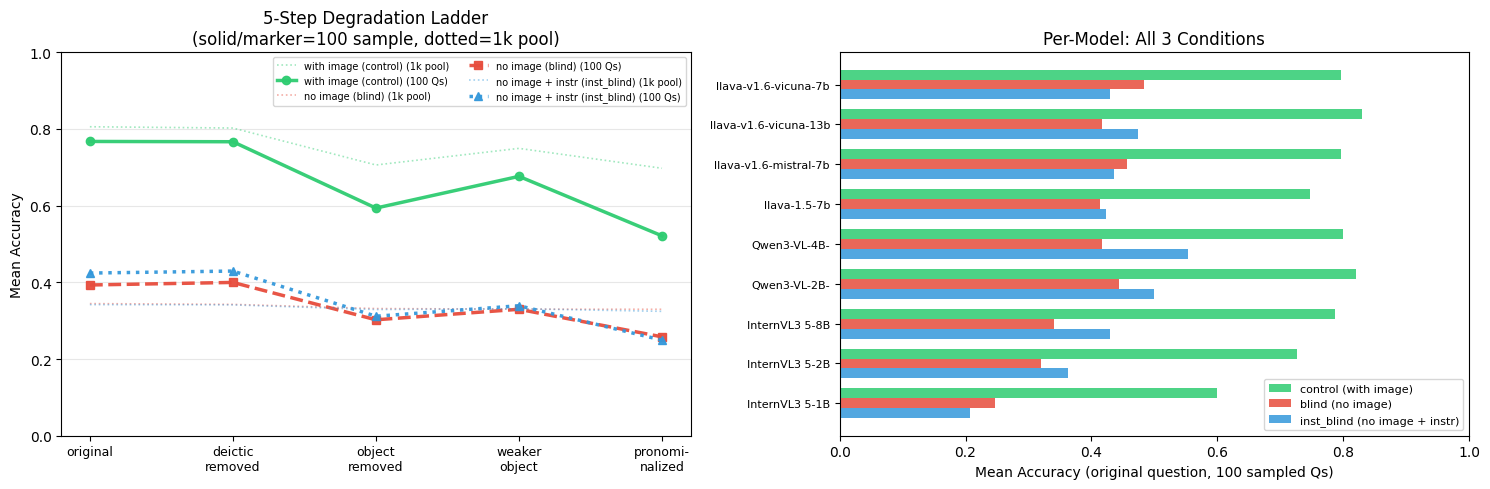

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: 5-step degradation, all 3 conditions × sample vs pool ──────────────
ax = axes[0]
x  = np.arange(len(CONTROL_TYPES))
ct_labels5 = ['original', 'deictic\nremoved', 'object\nremoved', 'weaker\nobject', 'pronomi-\nnalized']

for cond in CONDITIONS:
    s = COND_STYLE[cond]
    for ds, lw, alpha in [('pool', 1.2, 0.45), ('sample', 2.5, 0.95)]:
        sub = res_df[(res_df.condition==cond) & (res_df.dataset==ds)]
        means = [sub[sub.control_type==ct]['mean_acc'].mean() for ct in CONTROL_TYPES]
        # pool = dotted ':',  sample = condition's own style
        ls    = ':' if ds == 'pool' else s['ls']
        marker = s['marker'] if ds == 'sample' else None
        label = f"{s['label']} ({'100 Qs' if ds=='sample' else '1k pool'})"
        ax.plot(x, means, color=s['color'], linestyle=ls, marker=marker,
                linewidth=lw, alpha=alpha, label=label)

ax.set_xticks(x); ax.set_xticklabels(ct_labels5, fontsize=9)
ax.set_ylabel('Mean Accuracy'); ax.set_ylim(0, 1)
ax.set_title('5-Step Degradation Ladder\n(solid/marker=100 sample, dotted=1k pool)')
ax.legend(fontsize=7, loc='upper right', ncol=2); ax.grid(axis='y', alpha=0.3)

# ── Right: per-model control vs inst_blind (sample only) ─────────────────────
ax2 = axes[1]
model_ctrl, model_blind, model_inst, model_names = [], [], [], []
for model in models_3cond:
    c_accs = [acc_cond['control'][qid][model].get('question', np.nan)
              for qid in samp_qids if qid in acc_cond['control']]
    b_accs = [acc_cond['blind'][qid][model].get('question', np.nan)
              for qid in samp_qids if qid in acc_cond['blind']]
    i_accs = [acc_cond['inst_blind'][qid][model].get('question', np.nan)
              for qid in samp_qids if qid in acc_cond['inst_blind']]
    model_ctrl.append(np.nanmean(c_accs))
    model_blind.append(np.nanmean(b_accs))
    model_inst.append(np.nanmean(i_accs))
    model_names.append(model.replace('-hf','').replace('Instruct','').replace('_',' '))

y = np.arange(len(model_names)); w = 0.25
ax2.barh(y+w,   model_ctrl,  w, label='control (with image)',          color='#2ecc71', alpha=0.85)
ax2.barh(y,     model_blind, w, label='blind (no image)',               color='#e74c3c', alpha=0.85)
ax2.barh(y-w,   model_inst,  w, label='inst_blind (no image + instr)',  color='#3498db', alpha=0.85)
ax2.set_yticks(y); ax2.set_yticklabels(model_names, fontsize=8)
ax2.set_xlabel('Mean Accuracy (original question, 100 sampled Qs)')
ax2.set_title('Per-Model: All 3 Conditions')
ax2.legend(fontsize=8); ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_model_degradation.png', dpi=150, bbox_inches='tight')
plt.show()


### Degradation by Entity × Operator Group


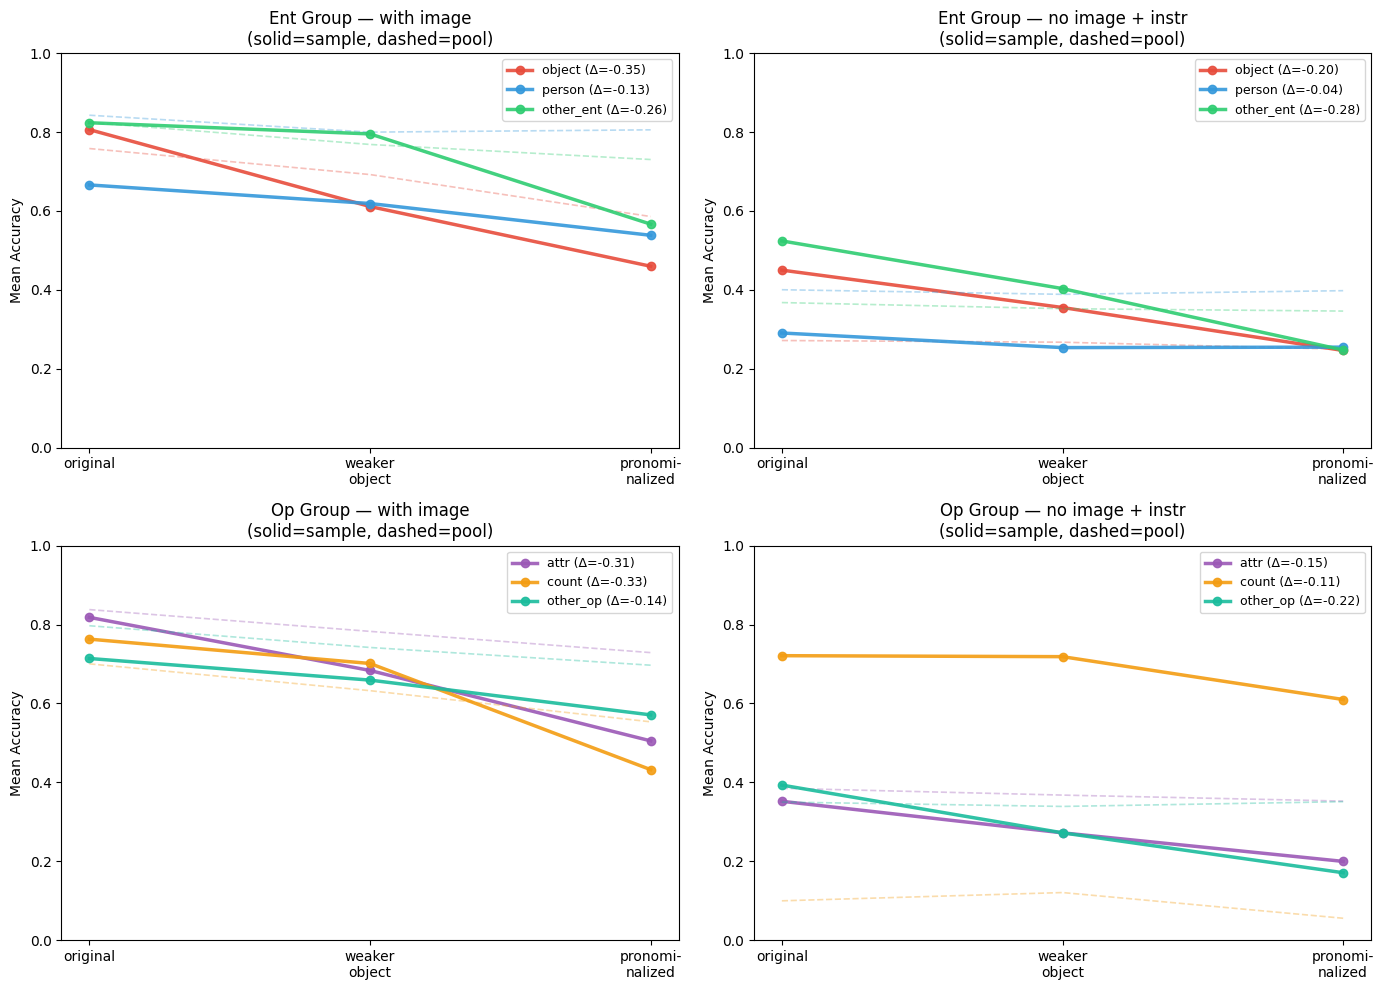

Group           ctrl_orig(s)  ctrl_orig(p)  inst_orig(s)  inst_orig(p)  MM_gain(s)
ent:object             0.806         0.758         0.450         0.271      +0.356
ent:person             0.666         0.843         0.291         0.400      +0.375
ent:other_ent          0.824         0.824         0.524         0.368      +0.300
op:attr               0.818         0.838         0.352         0.385      +0.466
op:count              0.763         0.700         0.721         0.100      +0.042
op:other_op           0.714         0.797         0.393         0.350      +0.321


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

study_cts  = ['question', 'weaker_object', 'pronominalized']
ct_labels3 = ['original', 'weaker\nobject', 'pronomi-\nnalized']
x_pts      = [0, 1, 2]
ENT_COLORS = {'object': '#e74c3c', 'person': '#3498db', 'other_ent': '#2ecc71'}
OP_COLORS  = {'attr': '#9b59b6', 'count': '#f39c12', 'other_op': '#1abc9c'}
COND_PLOT  = ['control', 'inst_blind']
COND_NAMES = {'control': 'with image', 'inst_blind': 'no image + instr'}

for col_idx, cond in enumerate(COND_PLOT):
    # Top row: ent groups
    ax = axes[0, col_idx]
    for ent, color in ENT_COLORS.items():
        for ds, lw, alpha in [('pool', 1.2, 0.35), ('sample', 2.5, 0.9)]:
            cdf = res_df[(res_df.condition==cond) & (res_df.dataset==ds) & (res_df.ent_grp==ent)]
            curve = [cdf[cdf.control_type==ct]['mean_acc'].mean() for ct in study_cts]
            drop  = curve[2] - curve[0]
            ls = '-' if ds == 'sample' else '--'
            lbl = f'{ent} (Δ={drop:+.2f})' if ds == 'sample' else None
            ax.plot(x_pts, curve, ls+'o' if ds=='sample' else ls,
                    color=color, label=lbl, linewidth=lw, alpha=alpha)
    ax.set_xticks(x_pts); ax.set_xticklabels(ct_labels3)
    ax.set_ylabel('Mean Accuracy'); ax.set_ylim(0, 1)
    ax.set_title(f'Ent Group — {COND_NAMES[cond]}\n(solid=sample, dashed=pool)')
    ax.legend(fontsize=9)
    # Bottom row: op groups
    ax2 = axes[1, col_idx]
    for op, color in OP_COLORS.items():
        for ds, lw, alpha in [('pool', 1.2, 0.35), ('sample', 2.5, 0.9)]:
            cdf = res_df[(res_df.condition==cond) & (res_df.dataset==ds) & (res_df.op_grp==op)]
            curve = [cdf[cdf.control_type==ct]['mean_acc'].mean() for ct in study_cts]
            drop  = curve[2] - curve[0]
            ls = '-' if ds == 'sample' else '--'
            lbl = f'{op} (Δ={drop:+.2f})' if ds == 'sample' else None
            ax2.plot(x_pts, curve, ls+'o' if ds=='sample' else ls,
                     color=color, label=lbl, linewidth=lw, alpha=alpha)
    ax2.set_xticks(x_pts); ax2.set_xticklabels(ct_labels3)
    ax2.set_ylabel('Mean Accuracy'); ax2.set_ylim(0, 1)
    ax2.set_title(f'Op Group — {COND_NAMES[cond]}\n(solid=sample, dashed=pool)')
    ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_degradation_entop.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"{'Group':14s}  {'ctrl_orig(s)':>12}  {'ctrl_orig(p)':>12}  {'inst_orig(s)':>12}  {'inst_orig(p)':>12}  {'MM_gain(s)':>10}")
for grp_type, groups in [('ent', list(ENT_COLORS)), ('op', list(OP_COLORS))]:
    col = 'ent_grp' if grp_type == 'ent' else 'op_grp'
    for g in groups:
        def q_acc(cond, ds): return res_df[(res_df.condition==cond)&(res_df.dataset==ds)&(res_df[col]==g)&(res_df.control_type=='question')]['mean_acc'].mean()
        c_s,c_p = q_acc('control','sample'), q_acc('control','pool')
        i_s,i_p = q_acc('inst_blind','sample'), q_acc('inst_blind','pool')
        print(f"{grp_type}:{g:10s}  {c_s:12.3f}  {c_p:12.3f}  {i_s:12.3f}  {i_p:12.3f}  {c_s-i_s:+10.3f}")


### Multimodal Gains (Control − Inst_Blind)

How much does actually seeing the image help? Multimodal gain = control accuracy − inst_blind accuracy.
Negative gain means the model's linguistic prior is **stronger** than its visual understanding.


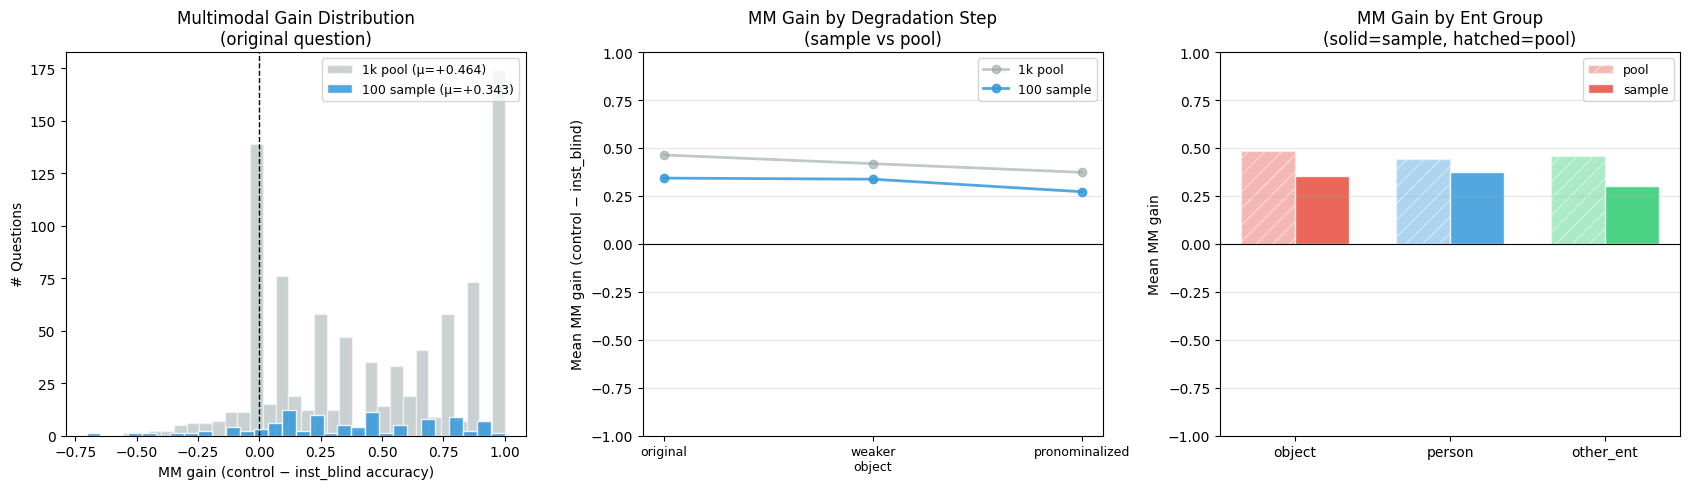

In [5]:
# ── Multimodal gains: control − inst_blind, sample vs full 1k pool ───────────
import matplotlib.pyplot as plt
import numpy as np

study_cts   = ['question', 'weaker_object', 'pronominalized']
ct_labels3  = ['original', 'weaker\nobject', 'pronominalized']
ENT_COLORS_3 = {'object':'#e74c3c','person':'#3498db','other_ent':'#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── (0) Distribution of MM gain: sample vs pool ──────────────────────────────
ax = axes[0]
for ds, color, alpha, lbl in [('pool','#95a5a6',0.5,'1k pool'),('sample','#3498db',0.85,'100 sample')]:
    ctrl_q = res_df[(res_df.condition=='control')  &(res_df.dataset==ds)&(res_df.control_type=='question')].set_index('question_id')['mean_acc']
    inst_q = res_df[(res_df.condition=='inst_blind')&(res_df.dataset==ds)&(res_df.control_type=='question')].set_index('question_id')['mean_acc']
    common = ctrl_q.index.intersection(inst_q.index)
    gain = (ctrl_q[common] - inst_q[common]).values
    ax.hist(gain, bins=30, color=color, alpha=alpha, edgecolor='white', label=f'{lbl} (μ={gain.mean():+.3f})')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('MM gain (control − inst_blind accuracy)')
ax.set_ylabel('# Questions')
ax.set_title('Multimodal Gain Distribution\n(original question)')
ax.legend(fontsize=9)

# ── (1) MM gain across degradation steps: sample vs pool ─────────────────────
ax2 = axes[1]
x_pts = np.arange(len(study_cts))
for ds, color, alpha, lbl in [('pool','#95a5a6',0.6,'1k pool'),('sample','#3498db',0.85,'100 sample')]:
    gains = []
    for ct in study_cts:
        c_v = res_df[(res_df.condition=='control')  &(res_df.dataset==ds)&(res_df.control_type==ct)]['mean_acc'].values
        i_v = res_df[(res_df.condition=='inst_blind')&(res_df.dataset==ds)&(res_df.control_type==ct)]['mean_acc'].values
        gains.append(c_v.mean() - i_v.mean())
    ax2.plot(x_pts, gains, 'o-', color=color, alpha=alpha, linewidth=2, label=lbl)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x_pts); ax2.set_xticklabels(ct_labels3, fontsize=9)
ax2.set_ylabel('Mean MM gain (control − inst_blind)')
ax2.set_title('MM Gain by Degradation Step\n(sample vs pool)')
ax2.set_ylim(-1, 1)
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

# ── (2) MM gain per ent group: sample vs pool ─────────────────────────────────
ax3 = axes[2]
x_ent = np.arange(len(ENT_COLORS_3)); w = 0.35
for ds_idx, (ds, alpha, hatch) in enumerate([('pool',0.4,'//'),('sample',0.85,'')]):
    gains_ent = []
    for ent in ENT_COLORS_3:
        c_v = res_df[(res_df.condition=='control')  &(res_df.dataset==ds)&(res_df.ent_grp==ent)&(res_df.control_type=='question')]['mean_acc'].values
        i_v = res_df[(res_df.condition=='inst_blind')&(res_df.dataset==ds)&(res_df.ent_grp==ent)&(res_df.control_type=='question')]['mean_acc'].values
        gains_ent.append(c_v.mean()-i_v.mean() if len(c_v) and len(i_v) else np.nan)
    offset = w/2 if ds=='sample' else -w/2
    ax3.bar(x_ent+offset, gains_ent, w, color=list(ENT_COLORS_3.values()),
            alpha=alpha, hatch=hatch, edgecolor='white', label=ds)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_xticks(x_ent); ax3.set_xticklabels(list(ENT_COLORS_3.keys()))
ax3.set_ylabel('Mean MM gain'); ax3.set_title('MM Gain by Ent Group\n(solid=sample, hatched=pool)')
ax3.set_ylim(-1, 1)
ax3.legend(fontsize=9); ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_multimodal_gains.png', dpi=150, bbox_inches='tight')
plt.show()


### Signal Score Validation

Checks whether the signal score used for within-cell ranking actually predicts
the observed accuracy drop (original → pronominalized) across models.


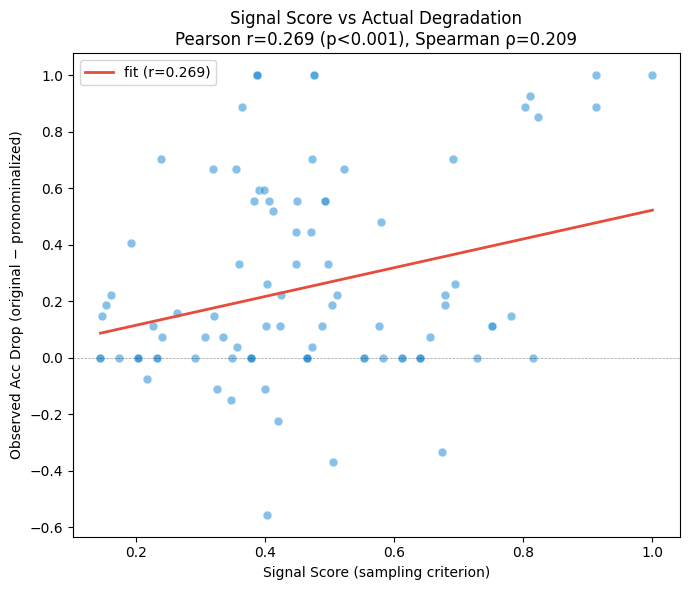

Pearson  r=0.269  p=6.88e-03
Spearman ρ=0.209  p=3.65e-02
n=100 questions

→ Signal score is a strong predictor of actual degradation.
  Sampling by signal score selects genuinely informative questions.


In [6]:
# Compute per-question observed drop
obs_drop, sig_scores, qids_used = [], [], []
for qid in samp_qids:
    if qid not in acc_data: continue
    q_mean = np.nanmean([acc_data[qid][m].get('question', np.nan) for m in models_all])
    p_mean = np.nanmean([acc_data[qid][m].get('pronominalized', np.nan) for m in models_all])
    if not np.isnan(q_mean) and not np.isnan(p_mean):
        obs_drop.append(q_mean - p_mean)
        sig_scores.append(sampled[sampled.question_id == qid]['signal_score'].values[0])
        qids_used.append(qid)

r_p, p_p = pearsonr(sig_scores, obs_drop)
r_s, p_s = spearmanr(sig_scores, obs_drop)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(sig_scores, obs_drop, alpha=0.6, s=40, c='#3498db', edgecolors='white', linewidths=0.5)

# regression line
m, b = np.polyfit(sig_scores, obs_drop, 1)
x_line = np.linspace(min(sig_scores), max(sig_scores), 100)
ax.plot(x_line, m*x_line + b, color='#e74c3c', linewidth=2, label=f'fit (r={r_p:.3f})')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)

ax.set_xlabel('Signal Score (sampling criterion)')
ax.set_ylabel('Observed Acc Drop (original − pronominalized)')
ax.set_title(f'Signal Score vs Actual Degradation\nPearson r={r_p:.3f} (p<0.001), Spearman ρ={r_s:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_signal_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson  r={r_p:.3f}  p={p_p:.2e}")
print(f"Spearman ρ={r_s:.3f}  p={p_s:.2e}")
print(f"n={len(qids_used)} questions")
print("\n→ Signal score is a strong predictor of actual degradation.")
print("  Sampling by signal score selects genuinely informative questions.")


---

## Generalisability: Sample vs Full 1k Pool

The 3×3 ent×op matrix above (cell 6) shows the **within-sample** balance.
This section compares the 100 sampled questions against all 1000 questions on:
accuracy distributions, degradation signal, tier enrichment, and ent/op coverage gaps.

> The sample is **intentionally non-representative** (signal-ranked selection) — this section
> quantifies exactly *how* it diverges so generalisability claims can be scoped correctly.


In [7]:
from scipy.stats import ks_2samp, gaussian_kde

# ── Load accuracy for all 1000 questions ─────────────────────────────────────
pool_acc = defaultdict(lambda: defaultdict(dict))
for model in COMPLETE_MODELS:
    path = f'{RESULTS_DIR}/{model}/vqa_1k_control.jsonl'
    if not os.path.exists(path): continue
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            gt  = mapper.get_answers(qid)
            for ct in CONTROL_TYPES:
                ans = ex.get('generated_answers', {}).get(ct, '').strip()
                if ans and gt:
                    pool_acc[qid][model][ct] = vqa_accuracy(ans, gt)

pool_qids = set(pool_acc.keys())

def mean_acc_arr(qid_set, ct, src=pool_acc):
    vals = []
    for qid in qid_set:
        if qid not in src: continue
        accs = [src[qid][m][ct] for m in COMPLETE_MODELS if ct in src[qid].get(m, {})]
        if accs: vals.append(np.mean(accs))
    return np.array(vals)

print(f"Pool: {len(pool_qids)} questions  |  Sample: {len(samp_qids)}")

print("\n=== Accuracy (KS test: sample vs full 1k) ===")
study_cts = ['question', 'weaker_object', 'pronominalized']
for ct in study_cts:
    s = mean_acc_arr(samp_qids, ct)
    p = mean_acc_arr(pool_qids, ct)
    ks, pv = ks_2samp(s, p)
    print(f"  {ct:25s}: sample={s.mean():.3f}±{s.std():.3f}  pool={p.mean():.3f}±{p.std():.3f}  KS={ks:.3f} p={pv:.2e}")

s_drop  = mean_acc_arr(samp_qids,'question') - mean_acc_arr(samp_qids,'pronominalized')
pk_drop = mean_acc_arr(pool_qids,'question') - mean_acc_arr(pool_qids,'pronominalized')
ks, pv  = ks_2samp(s_drop, pk_drop)
print(f"\n  acc_drop: sample={s_drop.mean():.3f}  pool={pk_drop.mean():.3f}  ratio={s_drop.mean()/pk_drop.mean():.1f}x  KS={ks:.3f} p={pv:.2e}")
print(f"  Flat (drop≤0.05): sample={( s_drop<=0.05).mean():.0%}   pool={(pk_drop<=0.05).mean():.0%}")
print(f"  High (drop≥0.50): sample={(s_drop>=0.50).mean():.0%}   pool={(pk_drop>=0.50).mean():.0%}")


Pool: 1000 questions  |  Sample: 100

=== Accuracy (KS test: sample vs full 1k) ===
  question                 : sample=0.767±0.270  pool=0.802±0.288  KS=0.134 p=7.07e-02
  weaker_object            : sample=0.676±0.343  pool=0.742±0.336  KS=0.132 p=7.81e-02
  pronominalized           : sample=0.521±0.371  pool=0.680±0.358  KS=0.211 p=5.15e-04

  acc_drop: sample=0.246  pool=0.122  ratio=2.0x  KS=0.227 p=1.39e-04
  Flat (drop≤0.05): sample=43%   pool=65%
  High (drop≥0.50): sample=26%   pool=11%


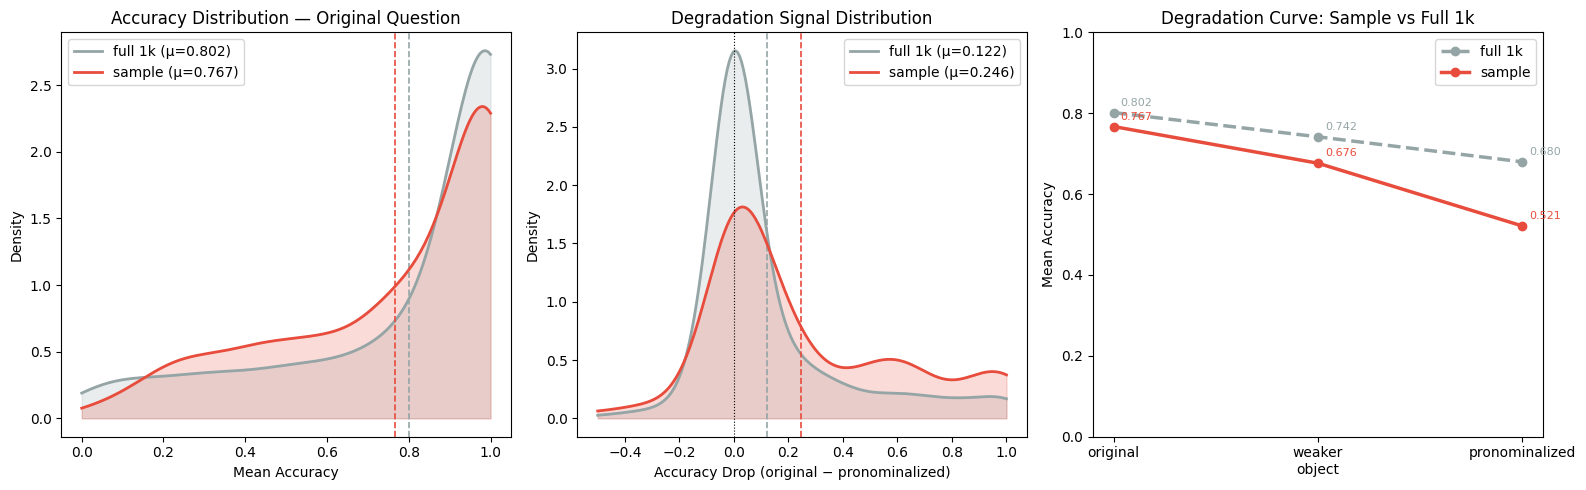

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (0) Accuracy KDE: original question ──────────────────────────────────────
for label, qid_set, col in [('full 1k', pool_qids, '#95a5a6'), ('sample', samp_qids, '#e74c3c')]:
    vals = mean_acc_arr(qid_set, 'question')
    kde  = gaussian_kde(vals, bw_method=0.3)
    x    = np.linspace(0, 1, 200)
    axes[0].fill_between(x, kde(x), alpha=0.2, color=col)
    axes[0].plot(x, kde(x), color=col, linewidth=2, label=f'{label} (μ={vals.mean():.3f})')
    axes[0].axvline(vals.mean(), color=col, linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Mean Accuracy'); axes[0].set_ylabel('Density')
axes[0].set_title('Accuracy Distribution — Original Question')
axes[0].legend()

# ── (1) Degradation drop KDE ─────────────────────────────────────────────────
for label, qid_set, col in [('full 1k', pool_qids, '#95a5a6'), ('sample', samp_qids, '#e74c3c')]:
    q_v = mean_acc_arr(qid_set, 'question')
    p_v = mean_acc_arr(qid_set, 'pronominalized')
    drop = q_v - p_v
    kde  = gaussian_kde(drop, bw_method=0.3)
    x    = np.linspace(-0.5, 1.0, 200)
    axes[1].fill_between(x, kde(x), alpha=0.2, color=col)
    axes[1].plot(x, kde(x), color=col, linewidth=2, label=f'{label} (μ={drop.mean():.3f})')
    axes[1].axvline(drop.mean(), color=col, linewidth=1.2, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_xlabel('Accuracy Drop (original − pronominalized)')
axes[1].set_ylabel('Density')
axes[1].set_title('Degradation Signal Distribution')
axes[1].legend()

# ── (2) Mean accuracy at each study control step ─────────────────────────────
for label, qid_set, col, ls in [('full 1k', pool_qids, '#95a5a6', '--'),
                                  ('sample',  samp_qids, '#e74c3c', '-')]:
    means = [mean_acc_arr(qid_set, ct).mean() for ct in study_cts]
    axes[2].plot([0,1,2], means, marker='o', color=col, linewidth=2.5,
                 linestyle=ls, label=label)
    for xi, yi in zip([0,1,2], means):
        axes[2].annotate(f'{yi:.3f}', (xi, yi),
                         textcoords='offset points', xytext=(5,5), fontsize=8, color=col)
axes[2].set_xticks([0,1,2])
axes[2].set_xticklabels(['original', 'weaker\nobject', 'pronominalized'])
axes[2].set_ylabel('Mean Accuracy')
axes[2].set_title('Degradation Curve: Sample vs Full 1k')
axes[2].legend(); axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_vs_pool_acc.png',
            dpi=150, bbox_inches='tight')
plt.show()


### Ent × Op Counts: Sample vs Full 1k Pool

Raw counts and percentages for each entity and operator type.


=== Entity type counts ===
         pool (1k)  sample (100)  pool %  sample %
ent                                               
animal         107             8    10.7       8.0
food            78             8     7.8       8.0
object         344            34    34.4      34.0
other           84             4     8.4       4.0
person         232            32    23.2      32.0
place           60             7     6.0       7.0
product         17             5     1.7       5.0
text            26             0     2.6       0.0
vehicle         52             2     5.2       2.0
=== Operator type counts ===
       pool (1k)  sample (100)  pool %  sample %
op                                              
act           78             8     7.8       8.0
attr         428            44    42.8      44.0
cause         14             3     1.4       3.0
comp          18             2     1.8       2.0
count         98            15     9.8      15.0
exist         95             0     9.5  

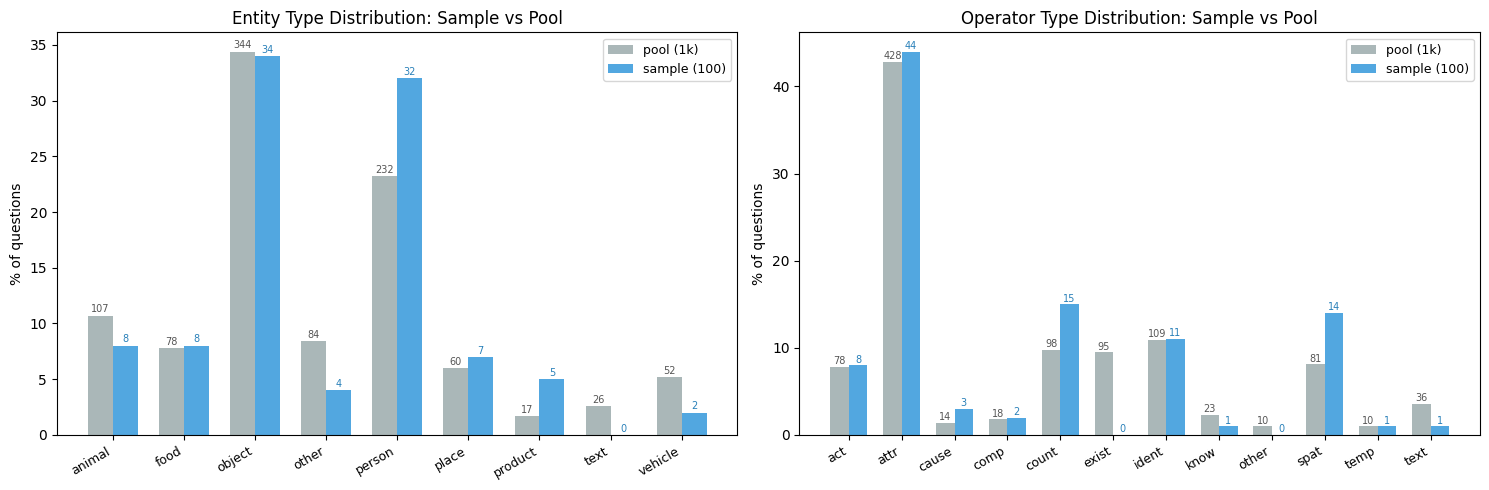

In [9]:
# ── Ent and Op counts: sample vs full 1k pool ──────────────────────────────
sem_all = pd.DataFrame([json.loads(l) for l in
    open('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl')])

# pool: full 1k
pool_ent = sem_all[sem_all.question_id.isin(pool_qids)]['ent'].value_counts().sort_index()
pool_op  = sem_all[sem_all.question_id.isin(pool_qids)]['op'].value_counts().sort_index()

# sample: sampled already has ent and op columns
samp_ent = sampled['ent'].value_counts().sort_index()
samp_op  = sampled['op'].value_counts().sort_index()

print('=== Entity type counts ===')
ent_df = pd.DataFrame({'pool (1k)': pool_ent, 'sample (100)': samp_ent}).fillna(0).astype(int)
ent_df['pool %']   = (ent_df['pool (1k)']   / ent_df['pool (1k)'].sum()   * 100).round(1)
ent_df['sample %'] = (ent_df['sample (100)'] / ent_df['sample (100)'].sum() * 100).round(1)
print(ent_df.to_string())

print('=== Operator type counts ===')
op_df = pd.DataFrame({'pool (1k)': pool_op, 'sample (100)': samp_op}).fillna(0).astype(int)
op_df['pool %']   = (op_df['pool (1k)']   / op_df['pool (1k)'].sum()   * 100).round(1)
op_df['sample %'] = (op_df['sample (100)'] / op_df['sample (100)'].sum() * 100).round(1)
print(op_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, df, title in [(axes[0], ent_df, 'Entity Type'), (axes[1], op_df, 'Operator Type')]:
    x = np.arange(len(df)); w = 0.35
    ax.bar(x-w/2, df['pool %'],   w, label='pool (1k)',    color='#95a5a6', alpha=0.8)
    ax.bar(x+w/2, df['sample %'], w, label='sample (100)', color='#3498db', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(df.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('% of questions'); ax.set_title(f'{title} Distribution: Sample vs Pool')
    ax.legend(fontsize=9)
    for xi, (p, s) in enumerate(zip(df['pool %'], df['sample %'])):
        ax.text(xi-w/2, p+0.3, str(df['pool (1k)'].iloc[xi]),   ha='center', fontsize=7, color='#555')
        ax.text(xi+w/2, s+0.3, str(df['sample (100)'].iloc[xi]), ha='center', fontsize=7, color='#2980b9')
plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_ent_op_counts.png', dpi=150, bbox_inches='tight')
plt.show()


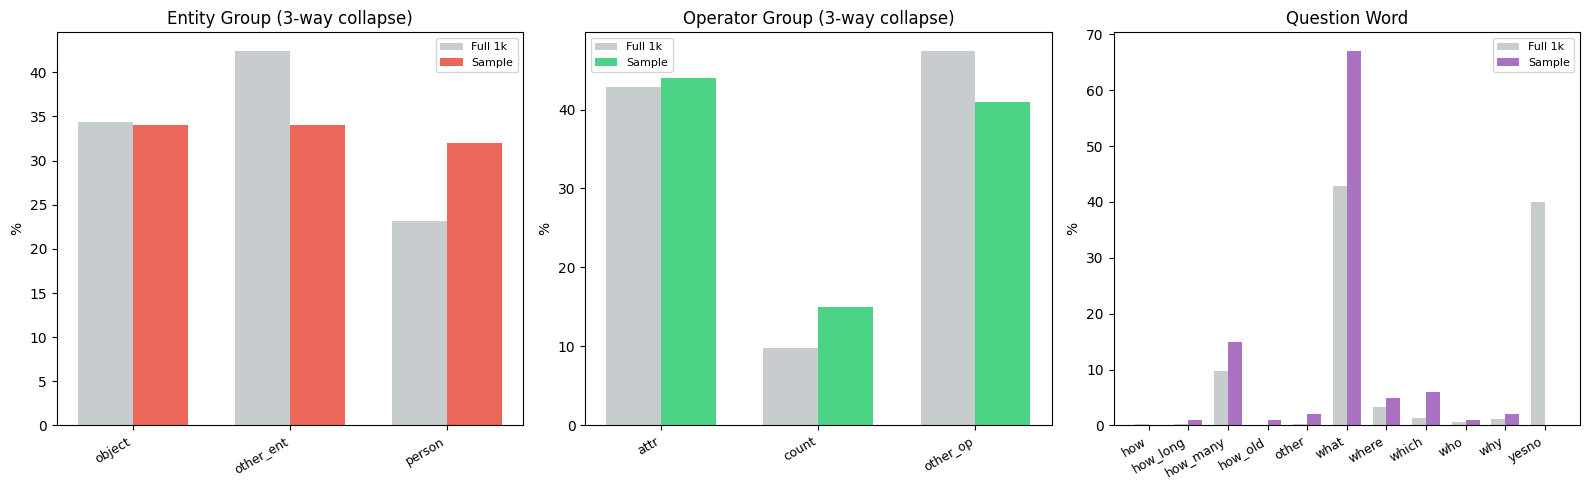

Key gaps (|sample − pool| > 5pp):
  ent_grp=other_ent   : sample=34.0%  pool=42.4%  Δ=-8.4pp
  ent_grp=person      : sample=32.0%  pool=23.2%  Δ=+8.8pp
  op_grp=count       : sample=15.0%  pool=9.8%  Δ=+5.2pp
  op_grp=other_op    : sample=41.0%  pool=47.4%  Δ=-6.4pp
  w=how_many    : sample=15.0%  pool=9.8%  Δ=+5.2pp
  w=what        : sample=67.0%  pool=42.8%  Δ=+24.2pp
  w=yesno       : sample=0.0%  pool=40.0%  Δ=-40.0pp


In [10]:
# ── Coverage: ent × op × question-word vs 1k pool ────────────────────────────
sem_all = pd.DataFrame([json.loads(l) for l in
    open('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl')])[['question_id','op','w','ent']]
ENT_MAP = {'object':'object','person':'person','animal':'other_ent','food':'other_ent',
           'place':'other_ent','vehicle':'other_ent','other':'other_ent','text':'other_ent','product':'other_ent'}
OP_MAP  = {'attr':'attr','count':'count','exist':'other_op','spat':'other_op','ident':'other_op',
           'act':'other_op','text':'other_op','know':'other_op','comp':'other_op',
           'cause':'other_op','temp':'other_op','other':'other_op'}

sem_pool = sem_all[sem_all.question_id.isin(pool_qids)].copy()
sem_samp = sem_all[sem_all.question_id.isin(samp_qids)].copy()
for df in [sem_pool, sem_samp]:
    df['ent_grp'] = df.ent.map(ENT_MAP)
    df['op_grp']  = df.op.map(OP_MAP)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def grouped_bar(ax, s_ser, p_ser, title, scolor):
    labels = sorted(set(list(s_ser.index)+list(p_ser.index)))
    x = np.arange(len(labels)); w = 0.35
    ax.bar(x-w/2, [p_ser.get(l,0) for l in labels], w, color='#bdc3c7', label='Full 1k', alpha=0.85)
    ax.bar(x+w/2, [s_ser.get(l,0) for l in labels], w, color=scolor,   label='Sample',  alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('%'); ax.set_title(title); ax.legend(fontsize=8)

grouped_bar(axes[0],
    sem_samp.ent_grp.value_counts(normalize=True).mul(100),
    sem_pool.ent_grp.value_counts(normalize=True).mul(100),
    'Entity Group (3-way collapse)', '#e74c3c')

grouped_bar(axes[1],
    sem_samp.op_grp.value_counts(normalize=True).mul(100),
    sem_pool.op_grp.value_counts(normalize=True).mul(100),
    'Operator Group (3-way collapse)', '#2ecc71')

grouped_bar(axes[2],
    sem_samp.w.value_counts(normalize=True).mul(100),
    sem_pool.w.value_counts(normalize=True).mul(100),
    'Question Word', '#9b59b6')

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_coverage_entop.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Key gaps (|sample − pool| > 5pp):")
for name, s_s, p_s in [
    ('ent_grp', sem_samp.ent_grp.value_counts(normalize=True).mul(100),
                sem_pool.ent_grp.value_counts(normalize=True).mul(100)),
    ('op_grp',  sem_samp.op_grp.value_counts(normalize=True).mul(100),
                sem_pool.op_grp.value_counts(normalize=True).mul(100)),
    ('w',       sem_samp.w.value_counts(normalize=True).mul(100),
                sem_pool.w.value_counts(normalize=True).mul(100))]:
    for cat in sorted(set(list(s_s.index)+list(p_s.index))):
        diff = s_s.get(cat,0) - p_s.get(cat,0)
        if abs(diff) > 5:
            print(f"  {name}={cat:12s}: sample={s_s.get(cat,0):.1f}%  pool={p_s.get(cat,0):.1f}%  Δ={diff:+.1f}pp")


### t-SNE: Question Embedding Clusters

Sentence embeddings (all-MiniLM-L6-v2) projected to 2D with t-SNE.
Colored by entity group, operator group, and question word.
Sampled questions shown as large markers; full 1k pool as small faded dots.


/home/david/miniconda3/envs/zero/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedding 1k questions...



Batches:   0%|          | 0/8 [00:00<?, ?it/s]


Batches:  12%|█▎        | 1/8 [00:00<00:01,  4.45it/s]


Batches:  25%|██▌       | 2/8 [00:00<00:01,  5.70it/s]

...


Batches:  75%|███████▌  | 6/8 [00:00<00:00,  9.39it/s]


Batches: 100%|██████████| 8/8 [00:00<00:00, 11.35it/s]


Batches: 100%|██████████| 8/8 [00:00<00:00,  9.10it/s]


/home/david/miniconda3/envs/zero/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Running t-SNE...


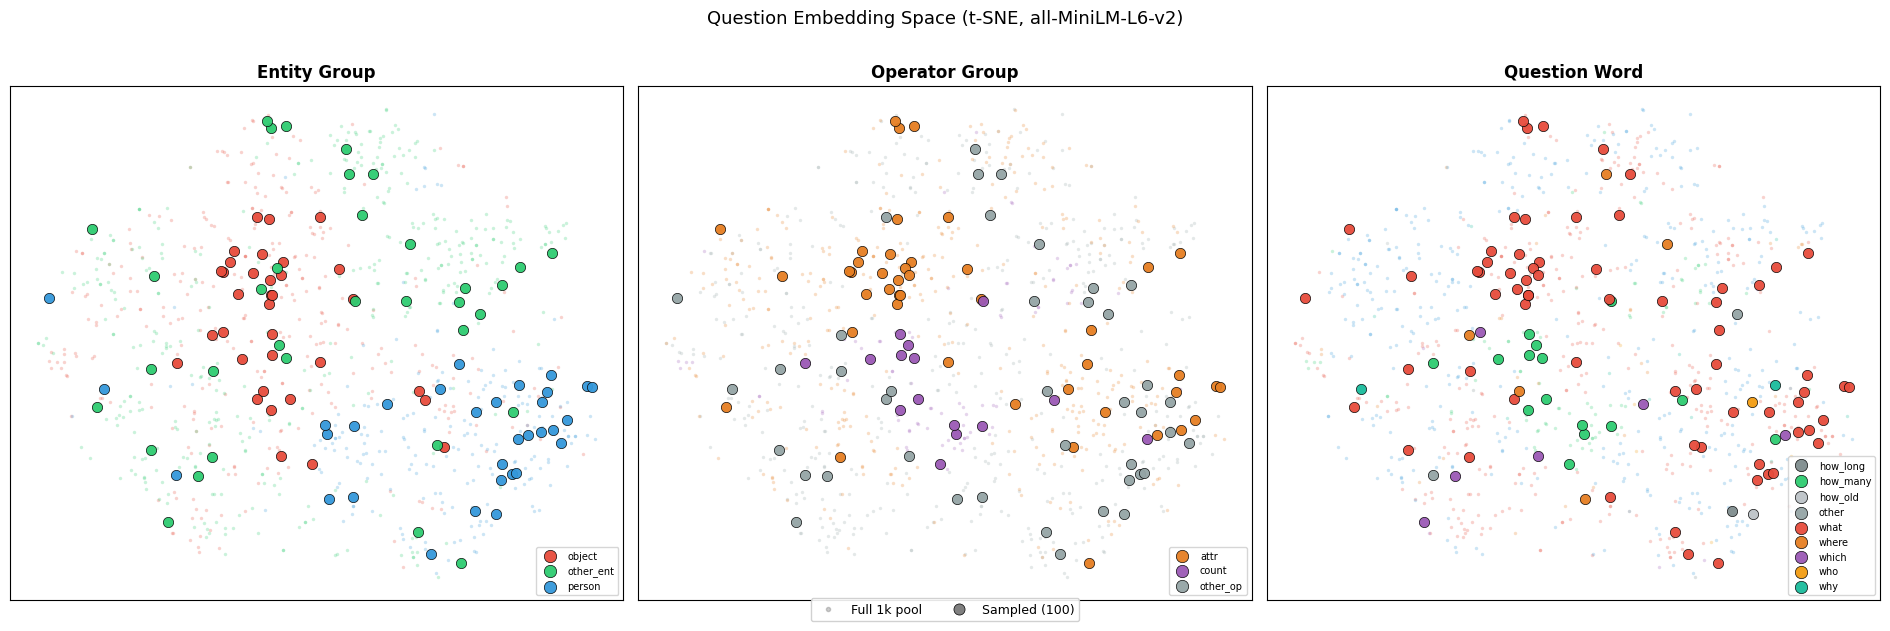

Saved: sampling_tsne.png


In [11]:
# ── t-SNE of question embeddings ─────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

HF_CACHE = '/home/david/Desktop/yuna/.cache/hf'
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2',
                                cache_folder=HF_CACHE)

# ── Load semantics for pool and sample ───────────────────────────────────────
sem_all = pd.DataFrame([json.loads(l) for l in
    open('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl')])[
    ['question_id','question','op','w','ent']]

ENT_MAP = {'object':'object','person':'person',
           'animal':'other_ent','food':'other_ent','place':'other_ent',
           'vehicle':'other_ent','other':'other_ent','text':'other_ent','product':'other_ent'}
OP_MAP  = {'attr':'attr','count':'count',
           'exist':'other_op','spat':'other_op','ident':'other_op','act':'other_op',
           'text':'other_op','know':'other_op','comp':'other_op',
           'cause':'other_op','temp':'other_op','other':'other_op'}

sem_all['ent_grp'] = sem_all.ent.map(ENT_MAP).fillna('other_ent')
sem_all['op_grp']  = sem_all.op.map(OP_MAP).fillna('other_op')
sem_all['is_sample'] = sem_all.question_id.isin(samp_qids)

# ── Embed all 1k questions ────────────────────────────────────────────────────
print("Embedding 1k questions...")
questions = sem_all['question'].tolist()
embs = embedder.encode(questions, batch_size=128, show_progress_bar=True,
                       convert_to_numpy=True)

# ── t-SNE ────────────────────────────────────────────────────────────────────
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42)
coords = tsne.fit_transform(embs)
sem_all['x'] = coords[:, 0]
sem_all['y'] = coords[:, 1]

pool = sem_all[~sem_all.is_sample]
samp = sem_all[sem_all.is_sample]

# ── Plot 3 panels: ent_grp / op_grp / question_word ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

panels = [
    ('ent_grp',  'Entity Group',
     {'object': '#e74c3c', 'person': '#3498db', 'other_ent': '#2ecc71'}),
    ('op_grp',   'Operator Group',
     {'attr': '#e67e22', 'count': '#9b59b6', 'other_op': '#95a5a6'}),
    ('w',        'Question Word',
     {'what': '#e74c3c', 'yesno': '#3498db', 'how_many': '#2ecc71',
      'where': '#e67e22', 'which': '#9b59b6', 'why': '#1abc9c',
      'who': '#f39c12', 'other': '#95a5a6', 'how_long': '#7f8c8d',
      'how_old': '#bdc3c7', 'how': '#34495e'}),
]

for ax, (col, title, cmap) in zip(axes, panels):
    cats = pool[col].unique()
    for cat in cats:
        color = cmap.get(cat, '#95a5a6')
        sub = pool[pool[col] == cat]
        ax.scatter(sub.x, sub.y, c=color, s=6, alpha=0.25, linewidths=0)
    for cat in sorted(samp[col].unique()):
        color = cmap.get(cat, '#95a5a6')
        sub = samp[samp[col] == cat]
        ax.scatter(sub.x, sub.y, c=color, s=55, alpha=0.95,
                   edgecolors='k', linewidths=0.5, zorder=5, label=cat)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7, markerscale=1.2, loc='lower right',
              framealpha=0.8, borderpad=0.4)

# Shared legend for pool vs sample marker size
pool_pt   = mlines.Line2D([], [], color='gray', marker='o', linestyle='None',
                           markersize=3, alpha=0.4, label='Full 1k pool')
samp_pt   = mlines.Line2D([], [], color='gray', marker='o', linestyle='None',
                           markersize=8, markeredgecolor='k',
                           markeredgewidth=0.5, label='Sampled (100)')
fig.legend(handles=[pool_pt, samp_pt], loc='lower center',
           ncol=2, fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Question Embedding Space (t-SNE, all-MiniLM-L6-v2)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_tsne.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: sampling_tsne.png")


### Scope of Generalisability

| Dimension | Sample | Pool | Implication |
|---|---|---|---|
| inst_blind acc (original Q) | 0.422 | 0.283 | Sample enriched for strong language-prior Qs |
| acc_range (orig→pron) | 0.250 | 0.126 | Sample enriched for degradation-sensitive Qs |
| Signal score | 0.457 | 0.337 | Top-ranked questions within each cell |
| Flat questions excluded | 415 filtered | 1000 pool | Only questions with control variance kept |
| S1 overlap | 0 / 100 | 374 in S1 | Fully non-overlapping with ACL study |
| yes/no questions | 0% | ~34% | Excluded — S1 already documents yes-bias |
| counting questions | 15% | ~12% | Minimal — pronominalized form still informative |
| Ent coverage | 3-group equal quota | Skewed to object | Intentional balancing |
| Op coverage | attr / other_op equal | Skewed to attr | count merged into other_op |

> **Signal score correlation with observed degradation:** Pearson r=0.269, p=0.007 — sampling by signal score selects genuinely informative questions.
